In [46]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class MACDBacktester():
    def __init__(self, symbol, fast_period=12, slow_period=26, signal_period=9, start=None, end=None):
        self.symbol = symbol
        self.fast_period = fast_period
        self.slow_period = slow_period
        self.signal_period = signal_period
        self.start = start
        self.end = end
        self.results = None
        self.get_data()
        
    def get_data(self):
        df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
        data = df.copy()
        data["returns"] = np.log(data.Close.div(data.Close.shift(1)))
        
        exp1 = data.Close.ewm(span=self.fast_period).mean()
        exp2 = data.Close.ewm(span=self.slow_period).mean()
        data["MACD"] = exp1 - exp2
        data["Signal"] = data.MACD.ewm(span=self.signal_period).mean()
        data["Histogram"] = data.MACD - data.Signal
        
        data.dropna(inplace=True)
        self.data2 = data
        return data
    
    def test_results(self):
        data = self.data2.copy().dropna()
        
        data["position"] = 0
        
        for i in range(1, len(data)):
            prev_position = data["position"].iloc[i-1]
            
            current_macd = data["MACD"].iloc[i]
            current_signal = data["Signal"].iloc[i]
            prev_macd = data["MACD"].iloc[i-1]
            prev_signal = data["Signal"].iloc[i-1]
            
            if (prev_macd >= prev_signal and current_macd < current_signal and 
                current_macd < 0 and prev_position == 0):
                data.iloc[i, data.columns.get_loc("position")] = -1
            
            elif (prev_macd <= prev_signal and current_macd > current_signal and 
                  current_macd > 0 and prev_position == 0):
                data.iloc[i, data.columns.get_loc("position")] = 1
            
            elif prev_position != 0:
                if prev_position == -1 and prev_macd <= 0 and current_macd > 0:
                    data.iloc[i, data.columns.get_loc("position")] = 0
                elif prev_position == 1 and prev_macd >= 0 and current_macd < 0:
                    data.iloc[i, data.columns.get_loc("position")] = 0
                else:
                    data.iloc[i, data.columns.get_loc("position")] = prev_position
            else:
                data.iloc[i, data.columns.get_loc("position")] = 0
        
        data["strategy"] = data["returns"] * data.position.shift(1)
        data.dropna(inplace=True)
        
        data["returnsbh"] = data["returns"].cumsum().apply(np.exp)
        data["returnsstrategy"] = data["strategy"].cumsum().apply(np.exp)
        
        perf = data["returnsstrategy"].iloc[-1]
        outperf = perf - data["returnsbh"].iloc[-1]
        
        self.results = data
        return round(perf, 6), round(outperf, 6)
    
    def plot_results(self):
        if self.results is None:
            print("Run the test please")
        else:
            title = "{} | MACD({},{},{})".format(self.symbol, self.fast_period, 
                                               self.slow_period, self.signal_period)
            self.results[["returnsbh", "returnsstrategy"]].plot(title=title, figsize=(12, 8))
            plt.show()
    
    def plot_macd(self):
        data = self.data2.copy()
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
        
        ax1.plot(data.index, data.Close, label='Close Price', linewidth=1)
        ax1.set_title(f"{self.symbol} Price", fontsize=15)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(data.index, data.MACD, label='MACD Line', color='blue', linewidth=1)
        ax2.plot(data.index, data.Signal, label='Signal Line', color='red', linewidth=1)
        ax2.bar(data.index, data.Histogram, label='Histogram', alpha=0.3, color='gray')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        ax2.set_title(f"MACD({self.fast_period},{self.slow_period},{self.signal_period})", fontsize=15)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def plot_signals(self):
        if self.results is None:
            print("Run the test please")
            return
            
        data = self.results.copy()
        
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))
        
        ax1.plot(data.index, data.Close, label='Close Price', linewidth=1)
        
        buy_signals = data[data.position.diff() == 1]
        ax1.scatter(buy_signals.index, buy_signals.Close, color='green', 
                   marker='^', s=100, label='Buy Signal')
        
        sell_signals = data[data.position.diff() == -1]
        ax1.scatter(sell_signals.index, sell_signals.Close, color='red', 
                   marker='v', s=100, label='Sell Signal')
        
        close_signals = data[(data.position.shift(1) != 0) & (data.position == 0)]
        ax1.scatter(close_signals.index, close_signals.Close, color='orange', 
                   marker='x', s=100, label='Close Signal')
        
        ax1.set_title(f"{self.symbol} Trading Signals", fontsize=15)
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        ax2.plot(data.index, data.MACD, label='MACD Line', color='blue', linewidth=1)
        ax2.plot(data.index, data.Signal, label='Signal Line', color='red', linewidth=1)
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5)
        ax2.set_title(f"MACD({self.fast_period},{self.slow_period},{self.signal_period})", fontsize=15)
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    
    def get_trade_summary(self):
        if self.results is None:
            print("Run the test please")
            return
            
        data = self.results.copy()
        
        position_changes = data.position.diff().fillna(0)
        long_entries = len(position_changes[position_changes == 1])
        short_entries = len(position_changes[position_changes == -1])
        
        strategy_returns = data["strategy"].dropna()
        total_trades = long_entries + short_entries
        winning_trades = len(strategy_returns[strategy_returns > 0])
        losing_trades = len(strategy_returns[strategy_returns < 0])
        
        if total_trades > 0:
            win_rate = winning_trades / len(strategy_returns[strategy_returns != 0]) * 100
        else:
            win_rate = 0
            
        print(f"Total trades: {total_trades}")
        print(f"Long trades: {long_entries}")
        print(f"Short trades: {short_entries}")
        print(f"Win rate: {win_rate:.2f}%")
        print(f"Average daily return: {strategy_returns.mean():.4f}")
        print(f"Return std: {strategy_returns.std():.4f}")

In [59]:
tester = MACDBacktester("TSLA", 12, 26, 9, "2020-06-25", "2025-06-25")

/var/folders/4z/0p4c7jt52_d1bq34q6bc_x800000gn/T/ipykernel_49680/472095383.py:19: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.symbol, start=self.start, end=self.end)[['Close']]
[*********************100%***********************]  1 of 1 completed


In [60]:
tester.test_results()

(0.944562, -4.376723)

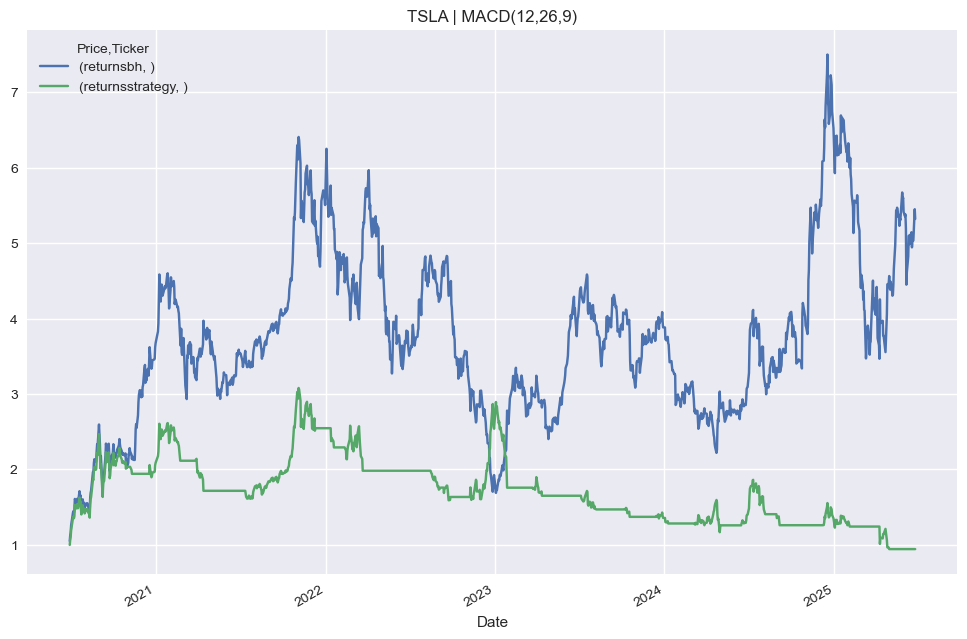

In [61]:
tester.plot_results()

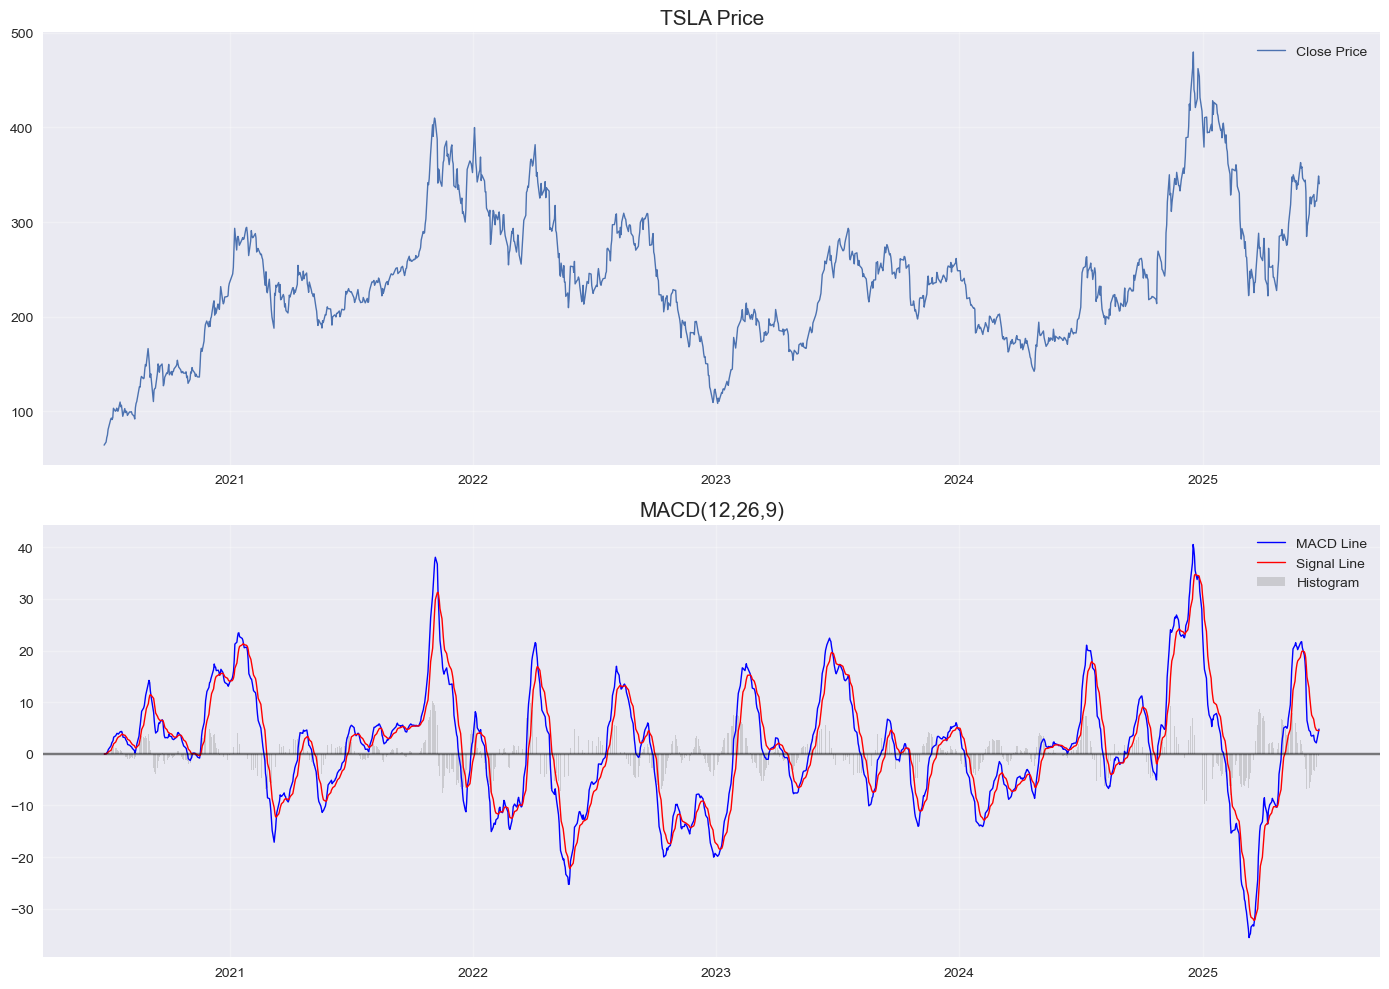

In [62]:
tester.plot_macd()

In [63]:
tester.get_trade_summary()

Total trades: 38
Long trades: 19
Short trades: 19
Win rate: 52.65%
Average daily return: -0.0000
Return std: 0.0277


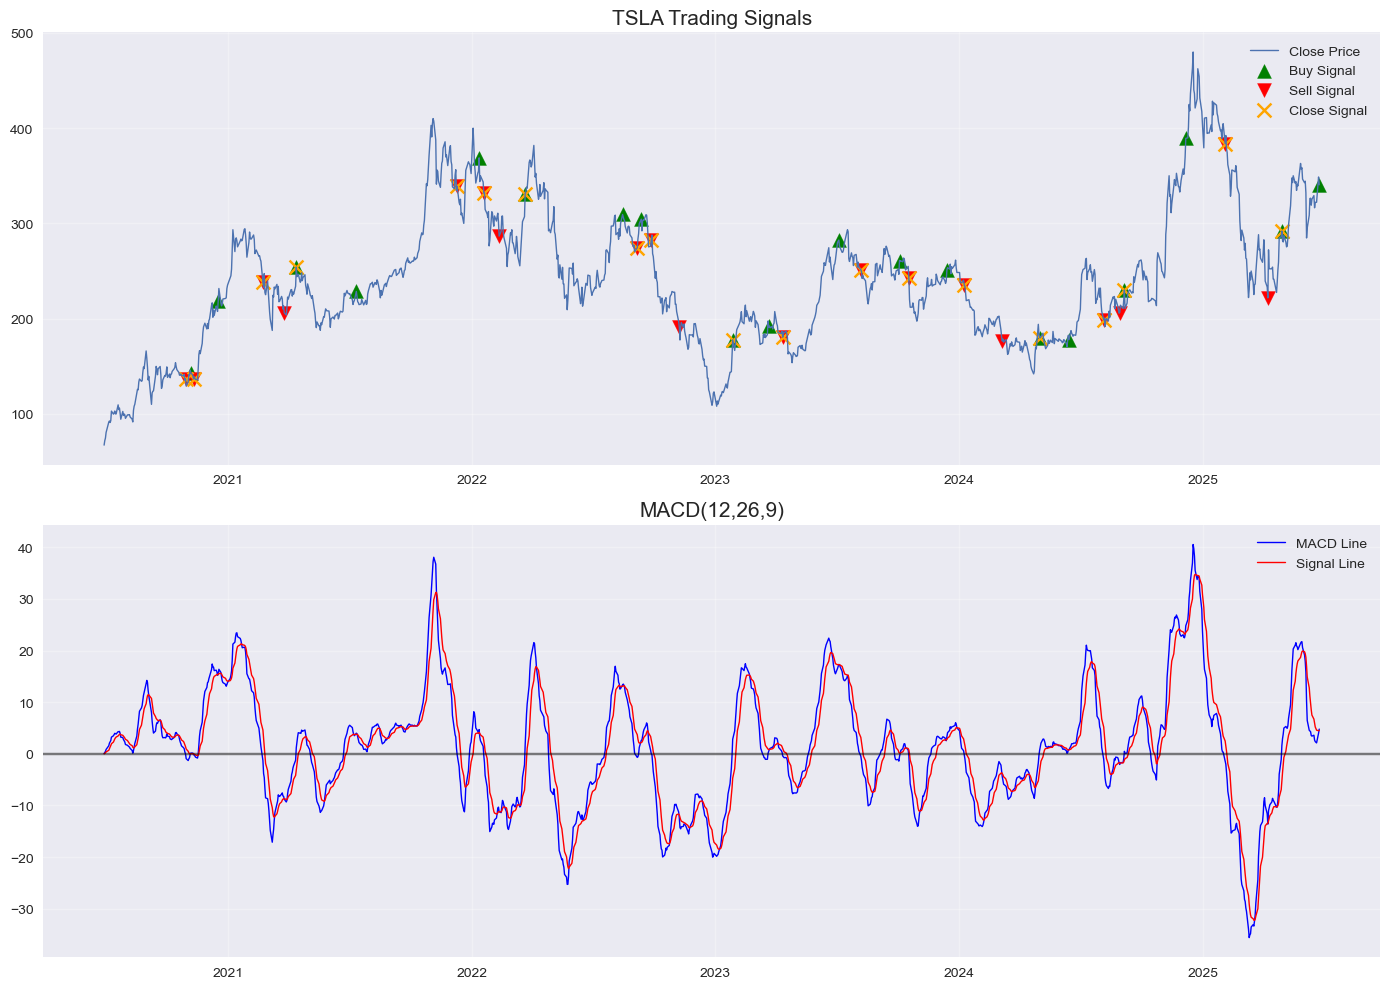

In [64]:
tester.plot_signals()